In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [39]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [11]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [47]:
block_size = 4 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y = [], []
    for w in words:
      
      #print(w)
      context = [0] * block_size
      for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
      
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [48]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [49]:
Xtr.shape

torch.Size([182625, 4])

In [63]:
dimension_for_char = 12
layer_size = 400

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((len(stoi), dimension_for_char), generator=g, requires_grad = True) # the C function in paper, this is what converts character to vector space
W1 = torch.randn((dimension_for_char * block_size, layer_size), generator=g, requires_grad = True) # first layer, takes in dimension_for_char * block_size as input so we will resize C to be that.
b1 = torch.randn(layer_size, generator=g, requires_grad = True) # bias for layer 1
W2 = torch.randn((layer_size, len(stoi)), generator=g, requires_grad = True) # second layer, has the same number of neurons as first one, outputs 27, the length of character space
b2 = torch.randn(len(stoi), generator=g, requires_grad = True) # bias for layer 2
parameters = [C, W1, b1, W2, b2]

# Finding good learning rate

In [64]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [67]:
lri = []
lossi = []

for i in range(1000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,)) # this is creating random batches of 32 like this - [1, 2, .., 32]
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr*p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())
print(loss.item())

19.42304229736328


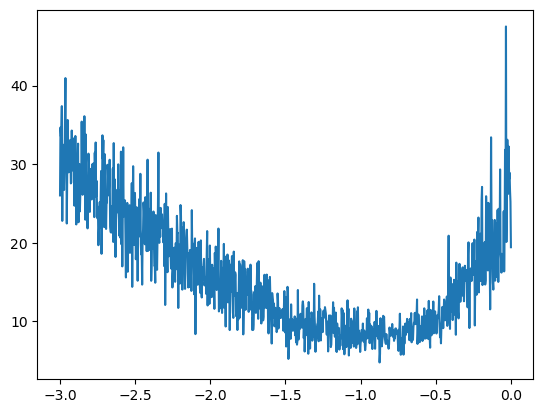

In [68]:
plt.plot(lri, lossi)

# Running with big learning rate

In [69]:
dimension_for_char = 12
layer_size = 400

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((len(stoi), dimension_for_char), generator=g, requires_grad = True) # the C function in paper, this is what converts character to vector space
W1 = torch.randn((dimension_for_char * block_size, layer_size), generator=g, requires_grad = True) # first layer, takes in dimension_for_char * block_size as input so we will resize C to be that.
b1 = torch.randn(layer_size, generator=g, requires_grad = True) # bias for layer 1
W2 = torch.randn((layer_size, len(stoi)), generator=g, requires_grad = True) # second layer, has the same number of neurons as first one, outputs 27, the length of character space
b2 = torch.randn(len(stoi), generator=g, requires_grad = True) # bias for layer 2
parameters = [C, W1, b1, W2, b2]

In [104]:
for i in range(10000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (1000,)) # this is creating random batches of 100 like this - [1, 2, .., 100]
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.001
    for p in parameters:
        p.data += -lr*p.grad
print(loss.item())

1.9634453058242798


In [105]:
# training loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0309, grad_fn=<NllLossBackward0>)

In [106]:
# dev set loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1167, grad_fn=<NllLossBackward0>)

In [107]:
# dev set loss
emb = C[Xte]
h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1117, grad_fn=<NllLossBackward0>)

# Tuning the initialization

In [116]:
dimension_for_char = 12
layer_size = 400

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((len(stoi), dimension_for_char), generator=g, requires_grad = True) # the C function in paper, this is what converts character to vector space
W1 = torch.randn((dimension_for_char * block_size, layer_size), generator=g, requires_grad = True) # first layer, takes in dimension_for_char * block_size as input so we will resize C to be that.
b1 = torch.randn(layer_size, generator=g, requires_grad = True) # bias for layer 1
W2 = torch.randn((layer_size, len(stoi)), generator=g, requires_grad = True) # second layer, has the same number of neurons as first one, outputs 27, the length of character space
b2 = torch.zeros(len(stoi), requires_grad = True) # bias for layer 2
parameters = [C, W1, b1, W2, b2]

In [130]:
for i in range(100000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (100,)) # this is creating random batches of 100 like this - [1, 2, .., 100]
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())

2.393127918243408


In [131]:
# training loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1375, grad_fn=<NllLossBackward0>)

In [132]:
# dev set loss
emb = C[Xte]
h = torch.tanh(emb.view(-1, dimension_for_char * block_size)@W1 + b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.2076, grad_fn=<NllLossBackward0>)

In [133]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khithrix.
thte.
salays.
emmaruel.
denryn.
jarquistellara.
chaily.
kaleigh.
hamorii.
dessyn.
shoista.
jadiquolue.
madiarynix.
kaegeigs.
toem.
emili.
gila.
hyla.
